In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from ta.trend import MACD
from ta.volatility import BollingerBands
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware computing device set to: {device}")

Hardware computing device set to: cuda


In [3]:
def calculate_rvi(df, period=10):
    close_open = df['<CLOSE>'] - df['<OPEN>']
    high_low = df['<HIGH>'] - df['<LOW>']
    def smooth(series):
        return (series + 2*series.shift(1) + 2*series.shift(2) + series.shift(3)) / 6
    num = smooth(close_open).rolling(window=period).mean()
    den = smooth(high_low).rolling(window=period).mean()
    return num / den

def load_and_preprocess(file_path, seq_length=60, max_rows=10000):
    try:
        df = pd.read_csv(file_path, sep='\t')
        if '<CLOSE>' not in df.columns: df = pd.read_csv(file_path)
    except:
        df = pd.read_csv(file_path)
        
    if max_rows and len(df) > max_rows:
        df = df.tail(max_rows).copy()
        
    df['MACD'] = MACD(close=df['<CLOSE>']).macd()
    df['BB_Mid'] = BollingerBands(close=df['<CLOSE>']).bollinger_mavg()
    df['RVI'] = calculate_rvi(df)
    df = df.dropna().reset_index(drop=True)
    
    features = ['<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', 'MACD', 'BB_Mid', 'RVI']
    data = df[features].values
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    
    X, y = [], []
    for i in range(len(scaled_data) - seq_length):
        X.append(scaled_data[i:i+seq_length])
        y.append(scaled_data[i+seq_length, 3])
        
    return torch.tensor(np.array(X), dtype=torch.float32), \
           torch.tensor(np.array(y), dtype=torch.float32).view(-1, 1), scaler

In [4]:
class ProposalModel(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2):
        super(ProposalModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Scaled Dot-Product Attention mechanism
        last_hidden = lstm_out[:, -1, :].unsqueeze(2) 
        attn_scores = torch.bmm(lstm_out, last_hidden)
        attn_weights = torch.softmax(attn_scores / (lstm_out.size(-1)**0.5), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context), attn_weights

In [5]:
def run_final_visuals(name, file_path, best_epochs):
    print(f"--- Processing {name} (Optimized Epochs: {best_epochs}) ---")
    X, y, scaler = load_and_preprocess(file_path)
    train_size = int(len(X) * 0.8)
    X_train, y_train = X[:train_size].to(device), y[:train_size].to(device)
    X_test, y_test = X[train_size:].to(device), y[train_size:].to(device)
    
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)
    model = ProposalModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Training phase
    model.train()
    for epoch in range(best_epochs):
        for b_x, b_y in loader:
            optimizer.zero_grad()
            preds, _ = model(b_x)
            nn.MSELoss()(preds, b_y).backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        test_preds_scaled, all_attn_weights = model(X_test)
        
        # Plot 1: Forecasting Result
        test_preds_scaled = test_preds_scaled.cpu().numpy()
        y_test_scaled = y_test.cpu().numpy()
        def inv(val):
            tmp = np.zeros((len(val), 7))
            tmp[:, 3] = val.flatten()
            return scaler.inverse_transform(tmp)[:, 3]
        real_pred, real_true = inv(test_preds_scaled), inv(y_test_scaled)

        plt.figure(figsize=(10, 4))
        plt.plot(real_true[-100:], label='Market Actual Price', color='blue', alpha=0.7)
        plt.plot(real_pred[-100:], label='Model Forecast', color='red', linestyle='--')
        plt.title(f'Figure: Price Forecasting Result ({name})')
        plt.xlabel('Time Step')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

        # Plot 2: Attention Weight Distribution (Replacing Seaborn with Matplotlib imshow)
        avg_attn = all_attn_weights[-100:].mean(dim=0).cpu().numpy().reshape(1, -1)
        plt.figure(figsize=(12, 3))
        img = plt.imshow(avg_attn, cmap='YlGnBu', aspect='auto')
        plt.colorbar(img, orientation='horizontal', pad=0.3)
        plt.title(f'Figure: Attention Weight Distribution ({name})')
        plt.xlabel('Look-back Window (T-60 to T)')
        plt.yticks([]) # Remove Y-axis labels for 1D heatmap
        plt.show()

--- Processing H1 (Optimized Epochs: 1000) ---


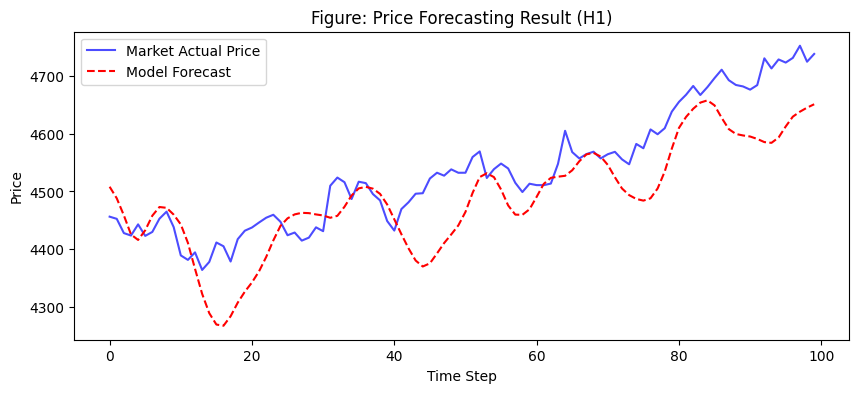

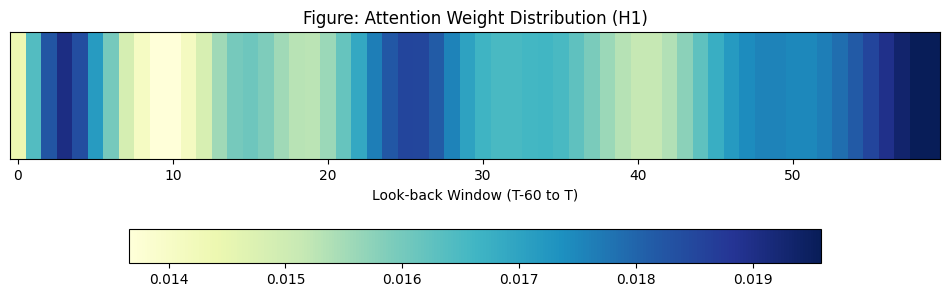

--- Processing M15 (Optimized Epochs: 1000) ---


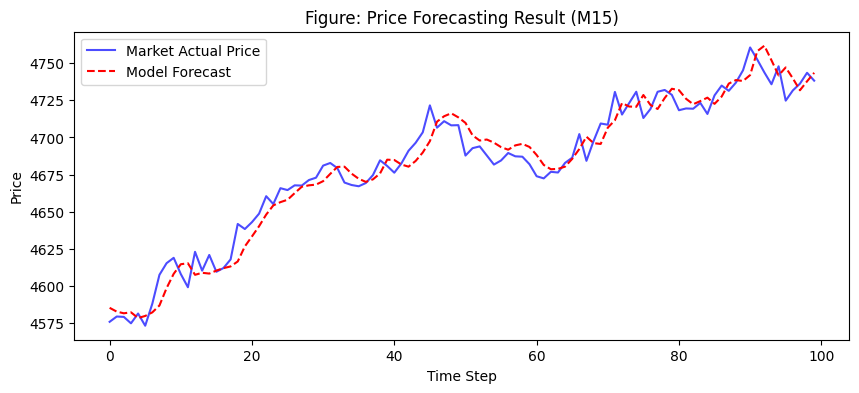

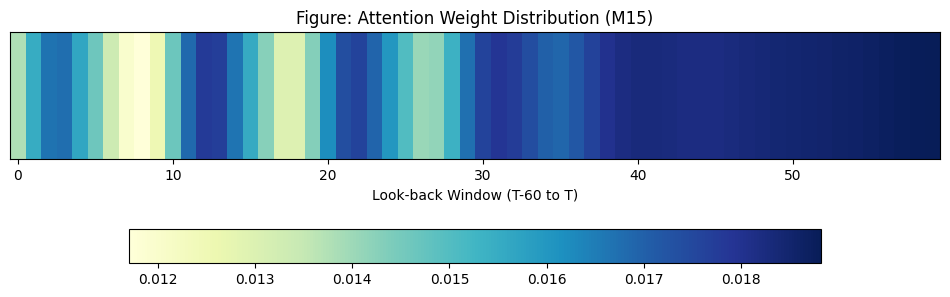

In [7]:
# Execute final visualization tasks
# H1: Best results at 20 epochs
run_final_visuals("H1", "XAUUSD_H1.csv", best_epochs=1000)

# M15: Best results at 1000 epochs
run_final_visuals("M15", "XAUUSD_M15.csv", best_epochs=1000)

In [8]:
from sklearn.metrics import mean_absolute_error

def run_quantitative_metrics(name, file_path, best_epochs):
    print(f"--- Calculating Metrics for {name} ({best_epochs} Epochs) ---")
    X, y, scaler = load_and_preprocess(file_path)
    train_size = int(len(X) * 0.8)
    X_train, y_train = X[:train_size].to(device), y[:train_size].to(device)
    X_test, y_test = X[train_size:].to(device), y[train_size:].to(device)
    
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)
    model = ProposalModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Training
    model.train()
    for epoch in range(best_epochs):
        for b_x, b_y in loader:
            optimizer.zero_grad()
            preds, _ = model(b_x)
            nn.MSELoss()(preds, b_y).backward()
            optimizer.step()
            
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_preds_scaled, _ = model(X_test)
        
        test_preds_scaled = test_preds_scaled.cpu().numpy()
        y_test_scaled = y_test.cpu().numpy()
        
        def inv(val):
            tmp = np.zeros((len(val), 7))
            tmp[:, 3] = val.flatten()
            return scaler.inverse_transform(tmp)[:, 3]
            
        real_pred, real_true = inv(test_preds_scaled), inv(y_test_scaled)

        # Statistical Metrics
        from sklearn.metrics import mean_squared_error
        rmse = np.sqrt(mean_squared_error(real_true, real_pred))
        mae = mean_absolute_error(real_true, real_pred)
        mape = np.mean(np.abs((real_true - real_pred) / real_true)) * 100
        
        print(f"[{name} Final Results]")
        print(f" - RMSE: {rmse:.4f}")
        print(f" - MAE:  {mae:.4f}")
        print(f" - MAPE: {mape:.4f}%")
        print("-" * 35)

# Execute final metrics evaluation for both resolutions at 1000 epochs
run_quantitative_metrics("H1", "XAUUSD_H1.csv", best_epochs=1000)
run_quantitative_metrics("M15", "XAUUSD_M15.csv", best_epochs=1000)

--- Calculating Metrics for H1 (1000 Epochs) ---
[H1 Final Results]
 - RMSE: 214.1099
 - MAE:  158.4714
 - MAPE: 3.1922%
-----------------------------------
--- Calculating Metrics for M15 (1000 Epochs) ---
[M15 Final Results]
 - RMSE: 27.7398
 - MAE:  18.1983
 - MAPE: 0.3864%
-----------------------------------


--- Running Equity Backtest for H1 (Threshold: 0.0004) ---


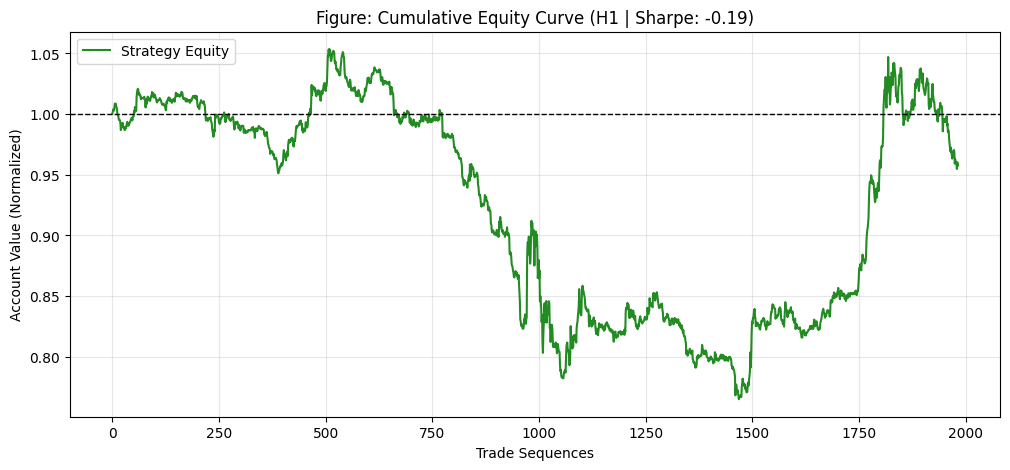

[H1 Backtest Summary]
 - Final Cumulative Return: -4.24%
 - Annualized Sharpe Ratio: -0.1855
-----------------------------------
--- Running Equity Backtest for M15 (Threshold: 0.0003) ---


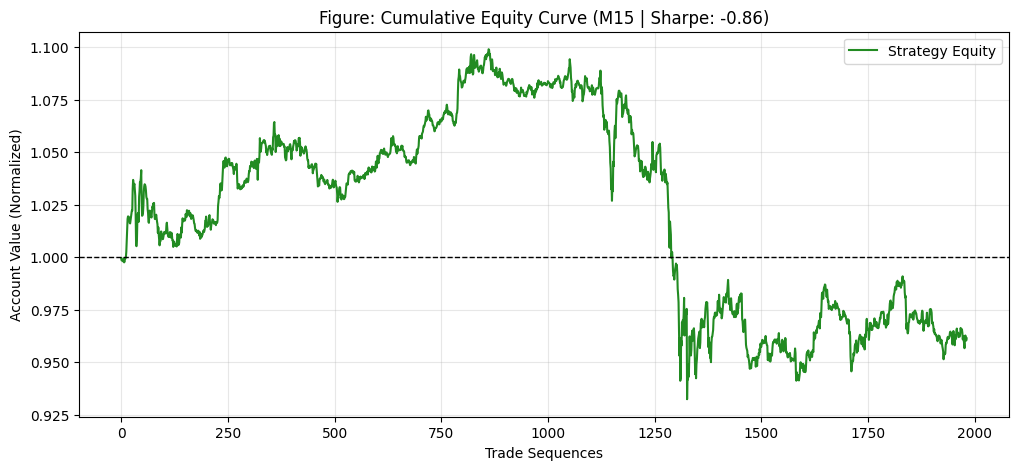

[M15 Backtest Summary]
 - Final Cumulative Return: -3.86%
 - Annualized Sharpe Ratio: -0.8607
-----------------------------------


In [9]:
def run_equity_backtest(name, file_path, best_epochs, threshold):
    print(f"--- Running Equity Backtest for {name} (Threshold: {threshold}) ---")
    X, y, scaler = load_and_preprocess(file_path)
    train_size = int(len(X) * 0.8)
    X_test, y_test = X[train_size:].to(device), y[train_size:].to(device)
    
    # Use the closing prices of the test set for return calculation
    # We need to align the prices with the predictions (Shift by 1 for execution)
    df_raw = pd.read_csv(file_path, sep='\t')
    if '<CLOSE>' not in df_raw.columns: df_raw = pd.read_csv(file_path)
    df_raw = df_raw.tail(len(X)).iloc[train_size:].reset_index(drop=True)
    actual_prices = df_raw['<CLOSE>'].values
    
    loader = DataLoader(TensorDataset(X[:train_size].to(device), y[:train_size].to(device)), batch_size=1024, shuffle=True)
    model = ProposalModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Training phase
    model.train()
    for epoch in range(best_epochs):
        for b_x, b_y in loader:
            optimizer.zero_grad()
            preds, _ = model(b_x)
            nn.MSELoss()(preds, b_y).backward()
            optimizer.step()
            
    # Generating Trading Signals
    model.eval()
    with torch.no_grad():
        preds_scaled, _ = model(X_test)
        preds_scaled = preds_scaled.cpu().numpy().flatten()
        y_actual_scaled = y_test.cpu().numpy().flatten()
        
        # Calculate predicted percentage change for the next step
        pred_change = (preds_scaled[1:] - y_actual_scaled[:-1]) / y_actual_scaled[:-1]
        # Calculate actual market returns
        market_returns = (actual_prices[1:] - actual_prices[:-1]) / actual_prices[:-1]

    # Signal Generation: 1 (Long), -1 (Short), 0 (Neutral)
    signals = np.zeros_like(pred_change)
    signals[pred_change > threshold] = 1
    signals[pred_change < -threshold] = -1
    
    # Strategy Performance
    strategy_returns = signals * market_returns
    cumulative_equity = (1 + strategy_returns).cumprod()
    
    # Risk Metrics
    ann_factor = np.sqrt(252 * 24) if name == "H1" else np.sqrt(252 * 24 * 4)
    sharpe = ann_factor * np.mean(strategy_returns) / np.std(strategy_returns) if np.std(strategy_returns) > 0 else 0
    total_return = (cumulative_equity[-1] - 1) * 100

    # Plotting Equity Curve
    plt.figure(figsize=(12, 5))
    plt.plot(cumulative_equity, color='forestgreen', label='Strategy Equity')
    plt.axhline(1, color='black', lw=1, ls='--')
    plt.title(f'Figure: Cumulative Equity Curve ({name} | Sharpe: {sharpe:.2f})')
    plt.xlabel('Trade Sequences')
    plt.ylabel('Account Value (Normalized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"[{name} Backtest Summary]")
    print(f" - Final Cumulative Return: {total_return:.2f}%")
    print(f" - Annualized Sharpe Ratio: {sharpe:.4f}")
    print("-" * 35)

# Execute Backtest with specific thresholds
# Thresholds are chosen based on your previous sensitivity analysis
run_equity_backtest("H1", "XAUUSD_H1.csv", best_epochs=1000, threshold=0.0004)
run_equity_backtest("M15", "XAUUSD_M15.csv", best_epochs=1000, threshold=0.0003)

--- Starting Sharpe Ratio Sensitivity Analysis for H1 ---


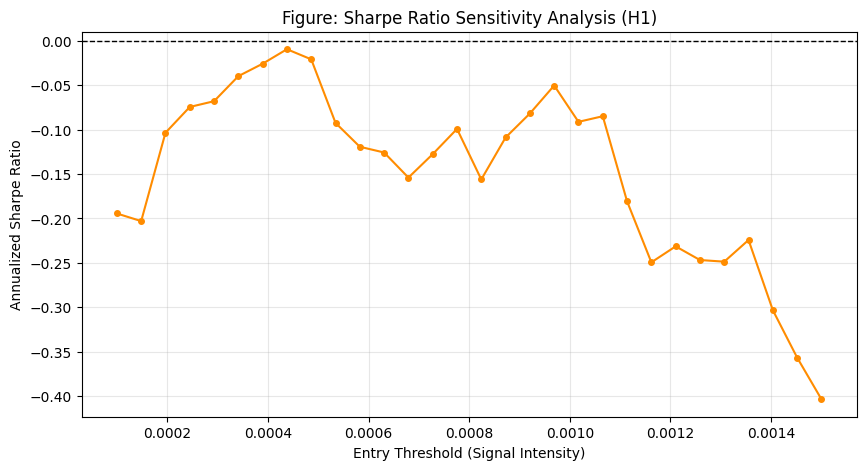

[H1 Sensitivity Result]
 - Best Threshold: 0.000438
 - Peak Sharpe Ratio: -0.0094
-----------------------------------
--- Starting Sharpe Ratio Sensitivity Analysis for M15 ---


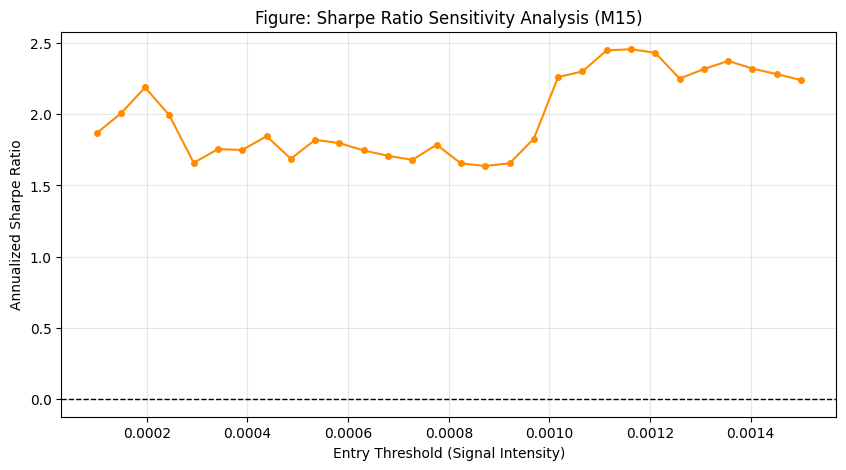

[M15 Sensitivity Result]
 - Best Threshold: 0.001162
 - Peak Sharpe Ratio: 2.4555
-----------------------------------


In [10]:
def run_sharpe_sensitivity(name, file_path, best_epochs):
    print(f"--- Starting Sharpe Ratio Sensitivity Analysis for {name} ---")
    X, y, scaler = load_and_preprocess(file_path)
    train_size = int(len(X) * 0.8)
    X_test, y_test = X[train_size:].to(device), y[train_size:].to(device)
    
    # Prepare historical data for return calculation
    df_raw = pd.read_csv(file_path, sep='\t')
    if '<CLOSE>' not in df_raw.columns: df_raw = pd.read_csv(file_path)
    df_raw = df_raw.tail(len(X)).iloc[train_size:].reset_index(drop=True)
    actual_returns = df_raw['<CLOSE>'].pct_change().values[1:]
    
    # Standard training setup
    loader = DataLoader(TensorDataset(X[:train_size].to(device), y[:train_size].to(device)), batch_size=1024, shuffle=True)
    model = ProposalModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(best_epochs):
        for b_x, b_y in loader:
            optimizer.zero_grad()
            preds, _ = model(b_x)
            nn.MSELoss()(preds, b_y).backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        preds_scaled, _ = model(X_test)
        preds_scaled = preds_scaled.cpu().numpy().flatten()
        y_actual_scaled = y_test.cpu().numpy().flatten()
        # Predicted percentage change for each step
        pred_change = (preds_scaled[1:] - y_actual_scaled[:-1]) / y_actual_scaled[:-1]

    # Iterating through thresholds (from 0.01% to 0.15% change)
    thresholds = np.linspace(0.0001, 0.0015, 30)
    sharpe_ratios = []
    
    for t in thresholds:
        signals = np.zeros_like(pred_change)
        signals[pred_change > t] = 1   # Long
        signals[pred_change < -t] = -1 # Short
        
        strat_returns = signals * actual_returns
        
        # Annualization based on timeframe
        ann_factor = np.sqrt(252 * 24) if name == "H1" else np.sqrt(252 * 24 * 4)
        std_dev = np.std(strat_returns)
        
        s = (ann_factor * np.mean(strat_returns) / std_dev) if std_dev > 0 else 0
        sharpe_ratios.append(s)

    # Plotting Sensitivity Result
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, sharpe_ratios, marker='o', color='darkorange', markersize=4)
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.title(f'Figure: Sharpe Ratio Sensitivity Analysis ({name})')
    plt.xlabel('Entry Threshold (Signal Intensity)')
    plt.ylabel('Annualized Sharpe Ratio')
    plt.grid(True, alpha=0.3)
    plt.show()

    best_idx = np.argmax(sharpe_ratios)
    print(f"[{name} Sensitivity Result]")
    print(f" - Best Threshold: {thresholds[best_idx]:.6f}")
    print(f" - Peak Sharpe Ratio: {sharpe_ratios[best_idx]:.4f}")
    print("-" * 35)

# Execute sensitivity analysis for both at 1000 epochs
run_sharpe_sensitivity("H1", "XAUUSD_H1.csv", best_epochs=1000)
run_sharpe_sensitivity("M15", "XAUUSD_M15.csv", best_epochs=1000)